# How to analyze some data taken with the flight code
1. Install the "shared" detector Python code: see `docs/python-setup.md`
2. Download example histogram data from [here](https://drive.google.com/file/d/1Y6O7j6YcSuH5bX7MCJSd7UMXr8jH_Yba) and extract it. The file contains 30s of background data.
3. Continue with the notebook

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from umndet import helpers

plt.style.use("style")
# Uncomment for high DPI screens
# %config InlineBackend.figure_format = 'retina'

In [2]:
# Load in the data file
data = helpers.read_bridgeport_debug("debug_hist.bin", open_func=open)

In [3]:
# Decode the data to Python dicts and look at some of it
decoded = [d.decode() for d in data]
trial = decoded[0]

print("keys available:")
print(trial.keys())

print("data type:")
print(trial["type"])

regs = np.array(trial["registers"])
print("histogram data:")
print(regs)

keys available:
dict_keys(['type', 'registers'])
data type:
fpga_histogram
histogram data:
[ 17  11  24 ...   0   0 381]


[Text(0.5, 0, 'ADC bin'),
 Text(0, 0.5, 'Counts'),
 Text(0.5, 1.0, 'Summation of 1 debug histograms'),
 None]

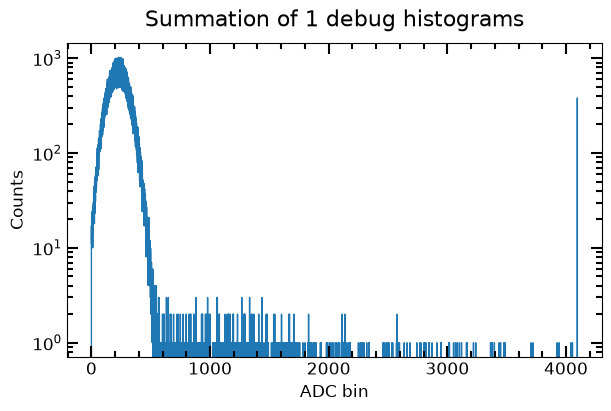

In [4]:
fig, ax = plt.subplots(layout="constrained", figsize=(6, 4))
bins = np.arange(regs.size + 1)
ax.stairs(regs, bins)
ax.set(
    xlabel="ADC bin",
    ylabel="Counts",
    title=f"Summation of {len(decoded)} debug histograms",
    yscale="log",
)